# Exploração dos dados de restrições

## Imports

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import find_dotenv, load_dotenv
import os
import gcsfs

## Unidades de Conservação

### Paths

In [2]:
dotenv_path = find_dotenv()
load_dotenv(dotenv_path)

project_root = os.path.dirname(dotenv_path)

KEY_PATH_RELATIVE = os.getenv("GOOGLE_APPLICATION_CREDENTIALS")
if KEY_PATH_RELATIVE:
    KEY_PATH_ABSOLUTE = os.path.join(project_root, KEY_PATH_RELATIVE)
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = KEY_PATH_ABSOLUTE
    print(f"Credenciais carregadas com sucesso de: {KEY_PATH_ABSOLUTE}")
else:
    print(
        "Aviso: A variável GOOGLE_APPLICATION_CREDENTIALS não foi encontrada no arquivo .env"
    )
    print("O acesso ao GCS pode falhar.")

BUCKET_NAME = os.getenv("GCS_BUCKET_NAME")
STATES_PATH = f"gs://{BUCKET_NAME}/raw/state_lines/BR_UF_2024.shp"
UCS_PATH = f"gs://{BUCKET_NAME}/raw/restrictions/cnuc_2025_08.shp"

Credenciais carregadas com sucesso de: g:\BackupC\Faculdade\UFRJ\TCC\analise-geografica-energia-solar-brasil\.secrets/tcc-usinas-solares-brasil-29b2750a20f8.json


### Carregamento de Dados

In [3]:
states_gdf = gpd.read_file(STATES_PATH)
ucs_gdf = gpd.read_file(UCS_PATH, encoding="cp1252")
print("Dados de Unidades de Conservação (UCs) carregados com sucesso!")

g:\BackupC\Faculdade\UFRJ\TCC\analise-geografica-energia-solar-brasil\.venv\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: One or several characters couldn't be converted correctly from cp1252 to UTF-8. This warning will not be emitted anymore
  return ogr_read(


Dados de Unidades de Conservação (UCs) carregados com sucesso!


### Inspeção Inicial dos Dados

In [4]:
print(f"\nSistema de Coordenadas (CRS): {ucs_gdf.crs}")
print(f"Quantidade de polígonos de UCs: {len(ucs_gdf)}")
print("Colunas:", list(ucs_gdf.columns))
print("\nAmostra dos dados:")
print(ucs_gdf.head())


Sistema de Coordenadas (CRS): EPSG:4674
Quantidade de polígonos de UCs: 3122
Colunas: ['gml_id', 'docleg_id', 'uc_id', 'cd_cnuc', 'wdpa_pid', 'nome_uc', 'cria_ano', 'cria_ato', 'outro_ato', 'pl_manejo', 'co_gestor', 'quali_pol', 'ppgr', 'ha_total', 'ha_ato', 'esfera', 'uf', 'municipio', 'org_gestor', 'grupo', 'categoria', 'cat_iucn', 'amazonia', 'caatinga', 'cerrado', 'matlantica', 'pampa', 'pantanal', 'marinho', 'situacao', 'limite', 'geometry']

Amostra dos dados:
  gml_id docleg_id uc_id       cd_cnuc   wdpa_pid  \
0   None         5     4  0000.00.0004      19752   
1   None        16    11  0000.00.0011  555600306   
2   None       403   275  0000.00.0275     351823   
3   None       925   981  0000.13.0981     352134   
4   None       928   984  0000.13.0984     352142   

                                             nome_uc    cria_ano  \
0  ÃREA DE PROTEÃ‡ÃƒO AMBIENTAL DA BACIA DO RIO S...  07-11-1983   
1  ÃREA DE PROTEÃ‡ÃƒO AMBIENTAL SERRA DA MANTIQUEIRA  06-06-1985   
2    

### Mapa Geral das UCs


Gerando mapa de Unidades de Conservação...


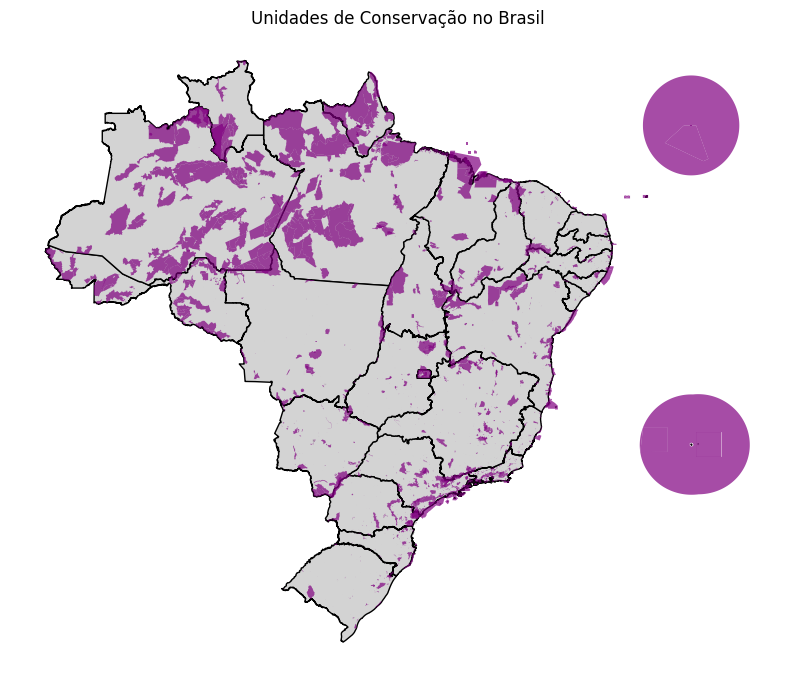

In [5]:
print("\nGerando mapa de Unidades de Conservação...")
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

states_gdf.plot(ax=ax, color="lightgray", edgecolor="black")
ucs_gdf.plot(ax=ax, color="purple", alpha=0.7)

ax.set_title("Unidades de Conservação no Brasil")
ax.set_axis_off()
plt.savefig(
    "../results/figures/unidades_conservacao_brasil.png", dpi=300, bbox_inches="tight"
)
plt.show()

### Mapa por Grupo de Proteção

In [6]:
ucs_gdf.head()

,gml_id,docleg_id,uc_id,cd_cnuc,wdpa_pid,nome_uc,cria_ano,cria_ato,outro_ato,pl_manejo,...,amazonia,caatinga,cerrado,matlantica,pampa,pantanal,marinho,situacao,limite,geometry
0,None,5,4,0000.00.0004,19752,ÃREA DE PROTEÃ‡ÃƒO AMBIENTAL DA BACIA DO RIO S...,07-11-1983,Decreto 88940 de 07-11-1983,Sem informaÃ§Ã£o,Sem informaÃ§Ã£o,...,None,None,82679.26,None,None,None,None,Ativo,uc,"MULTIPOLYGON (((-47.505 -15.58143, -47.5051 -1..."
1,None,16,11,0000.00.0011,555600306,ÃREA DE PROTEÃ‡ÃƒO AMBIENTAL SERRA DA MANTIQUEIRA,06-06-1985,Decreto 91304 de 03-06-1985,Sem informaÃ§Ã£o,Sim,...,None,None,None,437517.1,None,None,None,Ativo,uc,"POLYGON ((-44.75234 -21.92471, -44.7527 -21.92..."
2,None,403,275,0000.00.0275,351823,RESERVA BIOLÃ“GICA DAS PEROBAS,21-03-2006,Decreto S/N de 20-03-2006,Sem informaÃ§Ã£o,Sim,...,None,None,None,8716.1,None,None,None,Ativo,uc,"POLYGON ((-52.84028 -23.8589, -52.83847 -23.85..."
3,None,925,981,0000.13.0981,352134,RESERVA DE DESENVOLVIMENTO SUSTENTÃVEL AMANÃƒ,06-08-1998,Decreto 19021 de 04-08-1998,Sem informaÃ§Ã£o,Sem informaÃ§Ã£o,...,2303458.24,None,None,None,None,None,None,Ativo,uc,"POLYGON ((-63.3105 -1.53221, -63.31119 -1.5338..."
4,None,928,984,0000.13.0984,352142,RESERVA DE DESENVOLVIMENTO SUSTENTÃVEL CANUMÃƒ,23-05-2005,Decreto 25026 de 22-05-2005,Sem informaÃ§Ã£o,Sem informaÃ§Ã£o,...,22757.93,None,None,None,None,None,None,Ativo,uc,"POLYGON ((-58.84037 -3.85459, -58.84065 -3.857..."



Gerando mapa de UCs por Grupo de Proteção...


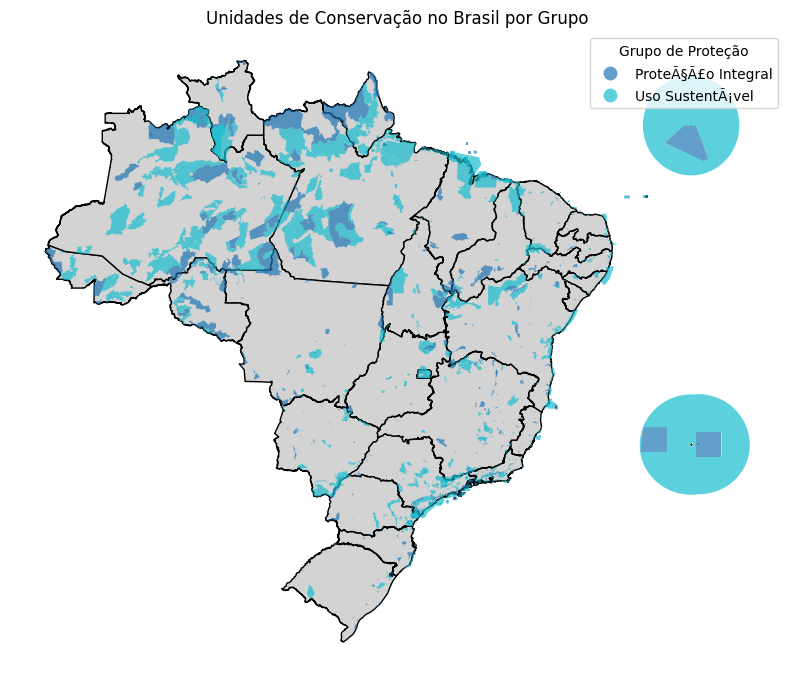

In [7]:
print("\nGerando mapa de UCs por Grupo de Proteção...")
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
states_gdf.plot(ax=ax, color="lightgray", edgecolor="black")

ucs_gdf.plot(
    ax=ax,
    column="grupo",
    categorical=True,
    legend=True,
    alpha=0.7,
    legend_kwds={"title": "Grupo de Proteção"},
)

ax.set_title("Unidades de Conservação no Brasil por Grupo")
ax.set_axis_off()
plt.show()

## Terras Indígenas

### Paths

In [8]:
TI_PATH = "../data/raw/restrictions/tis_poligonaisPolygon.shp"

### Carregamento de Dados

In [9]:
ti_gdf = gpd.read_file(TI_PATH, encoding="cp1252")
print("Dados de Terras Indígenas (TIs) carregados com sucesso!")

Dados de Terras Indígenas (TIs) carregados com sucesso!


g:\BackupC\Faculdade\UFRJ\TCC\analise-geografica-energia-solar-brasil\.venv\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: ../data/raw/restrictions/tis_poligonaisPolygon.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


### Inspeção Inicial dos Dados

In [10]:
print(f"\nSistema de Coordenadas (CRS): {ti_gdf.crs}")
print(f"Quantidade de polígonos de TIs: {len(ti_gdf)}")
print("Colunas:", list(ti_gdf.columns))
print("\nAmostra dos dados:")
print(ti_gdf.head())


Sistema de Coordenadas (CRS): EPSG:4674
Quantidade de polígonos de TIs: 638
Colunas: ['gid', 'terrai_cod', 'terrai_nom', 'etnia_nome', 'municipio_', 'uf_sigla', 'superficie', 'fase_ti', 'modalidade', 'reestudo_t', 'cr', 'faixa_fron', 'undadm_cod', 'undadm_nom', 'undadm_sig', 'dominio_un', 'data_atual', 'epsg', 'geometry']

Amostra dos dados:
   gid  terrai_cod        terrai_nom   etnia_nome municipio_ uf_sigla  \
0  1.0         101   Acapuri de Cima       Kokama  Fonte Boa       AM   
1  2.0         201             Acimã      Apurinã     Lábrea       AM   
2  3.0         401  Água Preta/Inari      Apurinã     Pauini       AM   
3  4.0         501       Águas Belas       Pataxó      Prado       BA   
4  5.0         601             Aconã  Tingui-Botó     Traipu       AL   

    superficie       fase_ti                modalidade reestudo_t  \
0   18393.9411  Regularizada  Tradicionalmente ocupada       None   
1   40686.0340  Regularizada  Tradicionalmente ocupada       None   
2  139763

### Mapa das Terras Indígenas


Gerando mapa de Terras Indígenas...


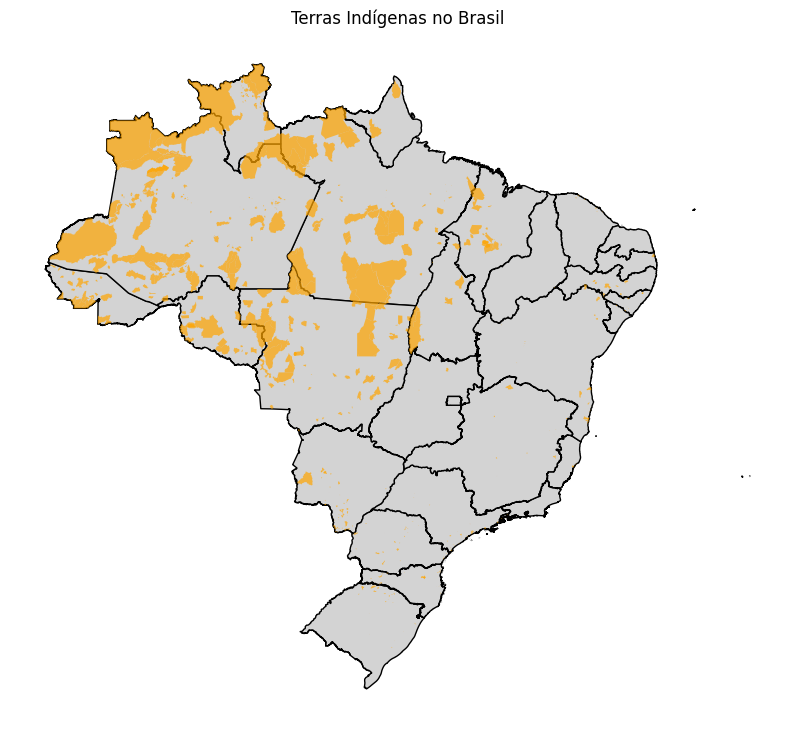

In [11]:
print("\nGerando mapa de Terras Indígenas...")
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
states_gdf.plot(ax=ax, color="lightgray", edgecolor="black")
ti_gdf.plot(ax=ax, color="orange", alpha=0.7)

ax.set_title("Terras Indígenas no Brasil")
ax.set_axis_off()
plt.savefig(
    "../results/figures/terras_indigenas_brasil.png", dpi=300, bbox_inches="tight"
)
plt.show()

## Assentamentos

### Paths

In [12]:
ASSENTAMENTOS_PATH = "../data/raw/restrictions/Assentamento Brasil.shp"

### Carregamento de Dados

In [13]:
assentamentos_gdf = gpd.read_file(ASSENTAMENTOS_PATH, encoding="cp1252")
print("Dados de Assentamentos Rurais carregados com sucesso!")

Dados de Assentamentos Rurais carregados com sucesso!


### Inspeção Inicial dos Dados

In [14]:
print(f"\nSistema de Coordenadas (CRS): {assentamentos_gdf.crs}")
print(f"Quantidade de polígonos de Assentamentos: {len(assentamentos_gdf)}")
print("Colunas:", list(assentamentos_gdf.columns))
print("\nAmostra dos dados:")
print(assentamentos_gdf.head())


Sistema de Coordenadas (CRS): EPSG:4674
Quantidade de polígonos de Assentamentos: 8220
Colunas: ['cd_sipra', 'uf', 'nome_proje', 'municipio', 'area_hecta', 'capacidade', 'num_famili', 'fase', 'data_de_cr', 'forma_obte', 'data_obten', 'area_calc_', 'sr', 'descricao_', 'geometry']

Amostra dos dados:
    cd_sipra  uf                nome_proje       municipio area_hecta  \
0  MB0417000  MB          PA RAINHA DA PAZ  RONDON DO PARA  2550.1304   
1  CE0047000  CE              PA GUANABARA     JAGUARETAMA  3789.8225   
2  CE0174000  CE  PA MALACACHETA/BOA VISTA          RUSSAS  1394.7145   
3  CE0156000  CE         PA OLHO D AGUA II   VARZEA ALEGRE   655.0314   
4  CE0352000  CE            PA SANTA LUZIA         CAMOCIM   170.2318   

   capacidade  num_famili  fase  data_de_cr      forma_obte  data_obten  \
0          52          51     3  22/12/2004  Compra e Venda  22/12/2004   
1          86          81     6  16/08/1989  Desapropriação  21/02/1989   
2          35          28     6  14

### Mapa dos Assentamentos


Gerando mapa de Assentamentos Rurais...


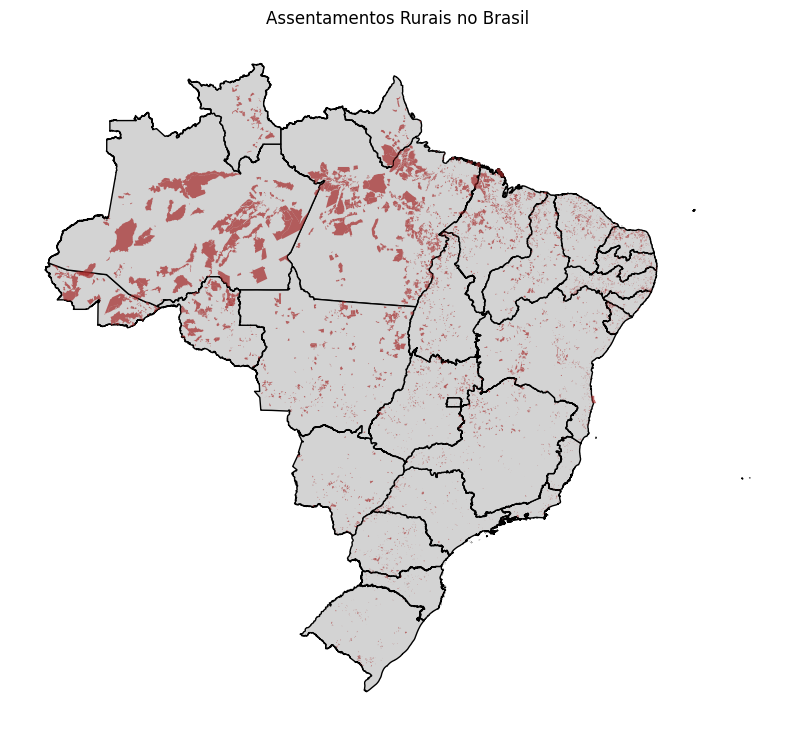

In [15]:
print("\nGerando mapa de Assentamentos Rurais...")
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
states_gdf.plot(ax=ax, color="lightgray", edgecolor="black")
assentamentos_gdf.plot(ax=ax, color="brown", alpha=0.7)

ax.set_title("Assentamentos Rurais no Brasil")
ax.set_axis_off()
plt.savefig(
    "../results/figures/assentamentos_rurais_brasil.png", dpi=300, bbox_inches="tight"
)
plt.show()

## Áreas Quilombolas

### Paths

In [16]:
QUILOMBOLAS_PATH = "../data/raw/restrictions/Áreas de Quilombolas.shp"

### CArregamento de Dados

In [17]:
quilombolas_gdf = gpd.read_file(QUILOMBOLAS_PATH, encoding="cp1252")
print("Dados de Territórios Quilombolas carregados com sucesso!")

Dados de Territórios Quilombolas carregados com sucesso!


### Inspeção Inicial

In [18]:
print(f"\nSistema de Coordenadas (CRS): {quilombolas_gdf.crs}")
print(f"Quantidade de polígonos: {len(quilombolas_gdf)}")
print("Colunas:", list(quilombolas_gdf.columns))
print("\nAmostra dos dados:")
print(quilombolas_gdf.head())


Sistema de Coordenadas (CRS): EPSG:4674
Quantidade de polígonos: 432
Colunas: ['cd_quilomb', 'cd_sr', 'nr_process', 'nm_comunid', 'nm_municip', 'cd_uf', 'dt_publica', 'dt_public1', 'nr_familia', 'dt_titulac', 'nr_area_ha', 'nr_perimet', 'cd_sipra', 'ob_descric', 'st_titulad', 'dt_decreto', 'tp_levanta', 'nr_escalao', 'area_calc_', 'perimetro_', 'esfera', 'fase', 'responsave', 'geometry']

Amostra dos dados:
   cd_quilomb  cd_sr            nr_process  \
0        47.0  SR-06  54170.001467/2006-48   
1        61.0  SR-16  54290.000372/2005-60   
2         NaN  SR-12                  2997   
3         NaN  SR-01          2001/274.554   
4         NaN  SR-21  54350.000691.2008-66   

                                     nm_comunid  \
0                                       MARQUES   
1                            COLONIA SAO MIGUEL   
2                                       MUCAMBO   
3  ALTO ITACURUÇA, BAIXO ITACURUCA, BOM REMEDIO   
4                           SÃO TOMÉ DO APOREMA   

    

### Mapa das Áreas Quilombolas


Gerando mapa de Territórios Quilombolas...


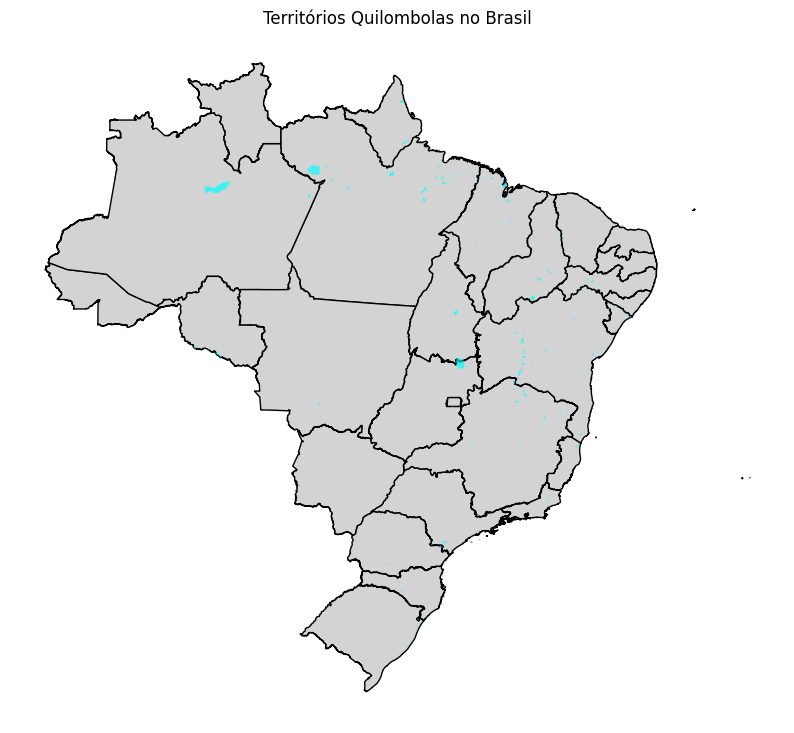

In [19]:
print("\nGerando mapa de Territórios Quilombolas...")
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

states_gdf.plot(ax=ax, color="lightgray", edgecolor="black")
quilombolas_gdf.plot(ax=ax, color="cyan", alpha=0.7)

ax.set_title("Territórios Quilombolas no Brasil")
ax.set_axis_off()
plt.savefig(
    "../results/figures/territorios_quilombolas_brasil.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Sítios Arqueológicos

### Paths

In [20]:
SITIOS_PATH = "../data/raw/restrictions/sitios.shp"

### Carregamento de Dados

In [21]:
sitios_gdf = gpd.read_file(SITIOS_PATH, encoding="cp1252")
print("Dados de Sítios Arqueológicos carregados com sucesso!")

Dados de Sítios Arqueológicos carregados com sucesso!


### Inspeção Inicial

In [22]:
print(f"\nSistema de Coordenadas (CRS): {sitios_gdf.crs}")
print(f"Quantidade de Sítios: {len(sitios_gdf)}")
print("Colunas:", list(sitios_gdf.columns))
print("\nAmostra dos dados:")
print(sitios_gdf.head())


Sistema de Coordenadas (CRS): EPSG:4674
Quantidade de Sítios: 30056
Colunas: ['id_bem', 'identifica', 'co_iphan', 'no_logrado', 'nu_logrado', 'id_naturez', 'ds_naturez', 'codigo_iph', 'id_classif', 'ds_classif', 'id_tipo_be', 'ds_tipo_be', 'sg_tipo_be', 'sintese_be', 'dt_cadastr', 'geometry']

Amostra dos dados:
   id_bem                 identifica            co_iphan no_logrado  \
0   51027            SITIO ATELIÊ ll  GO5203203BAST00017       None   
1   40914  Capela da Fazenda Surubím  BA2909901BAST00014       None   
2   49408         Córrego Barreiro I  MS5008008BAST00007       None   
3   52578              São Francisco  SP3511508BAST00001       None   
4   49193               Nakahara 138  AC1200179BAST00047       None   

  nu_logrado  id_naturez        ds_naturez codigo_iph  id_classif  \
0       None           3  Bem Arqueológico         BA          41   
1       None           3  Bem Arqueológico         BA          40   
2       None           3  Bem Arqueológico         

### Mapa dos Sítios Arqueológicos


Gerando mapa de Sítios Arqueológicos...


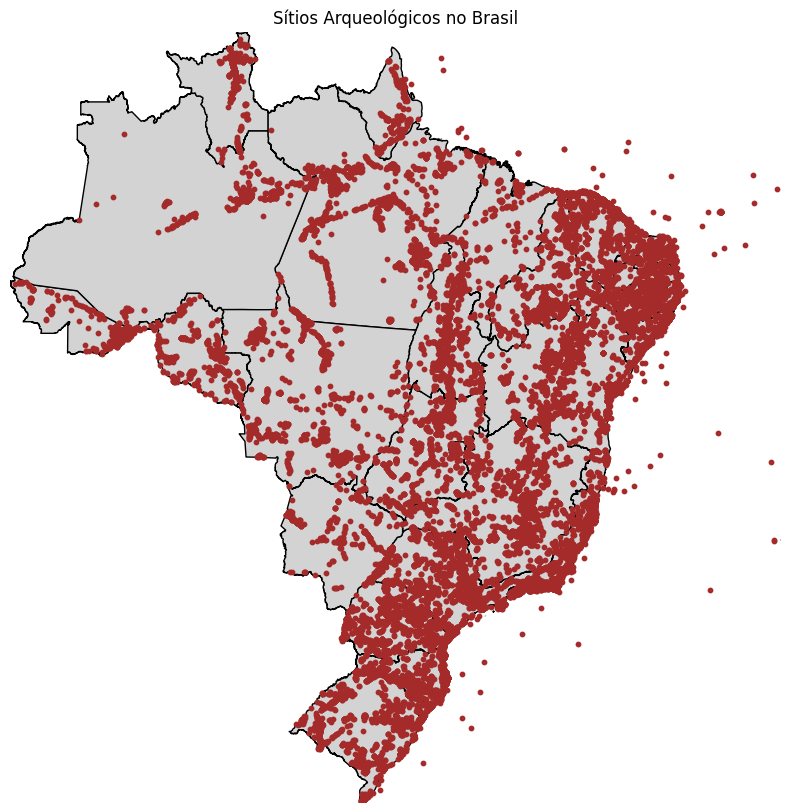

In [24]:
print("\nGerando mapa de Sítios Arqueológicos...")
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
states_gdf.plot(ax=ax, color="lightgray", edgecolor="black")

minx, miny, maxx, maxy = states_gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

sitios_gdf.plot(ax=ax, color="brown", markersize=10)

ax.set_title("Sítios Arqueológicos no Brasil")
ax.set_axis_off()
plt.savefig(
    "../results/figures/sitios_arqueologicos_brasil.png", dpi=300, bbox_inches="tight"
)
plt.show()

### Criando buffer para "converter" pontos em áreas

In [31]:
print("Criando buffer para os Sítios Arqueológicos...")
sitios_proj = sitios_gdf.to_crs(epsg=31983)
buffer_sitios = sitios_proj.buffer(1000).to_crs(epsg=4674)

Criando buffer para os Sítios Arqueológicos...


### Mapa de sítios com buffers


Gerando mapa de Sítios Arqueológicos com buffer...


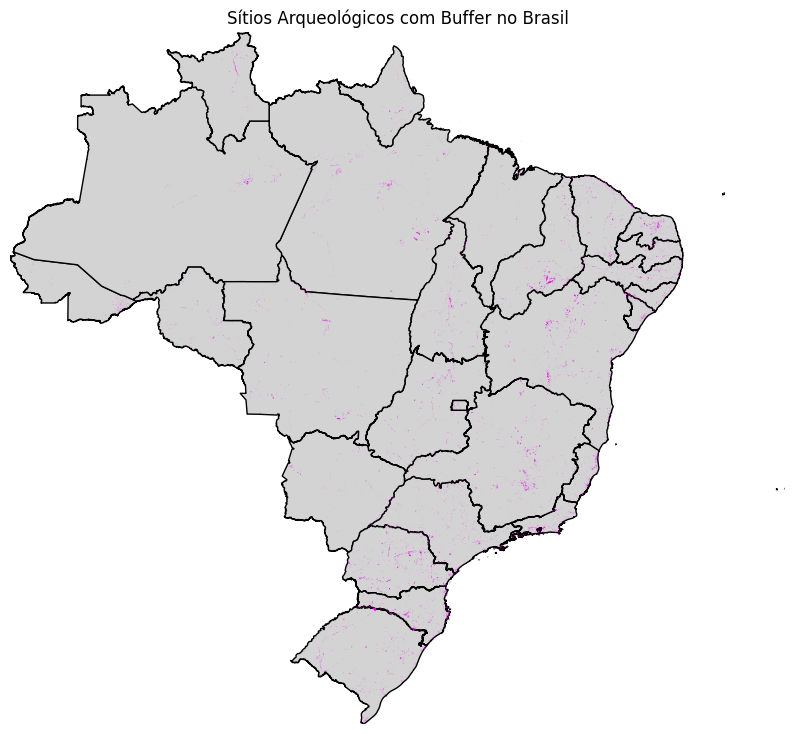

In [32]:
print("\nGerando mapa de Sítios Arqueológicos com buffer...")
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

minx, miny, maxx, maxy = states_gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

states_gdf.plot(ax=ax, color="lightgray", edgecolor="black")
buffer_sitios.plot(ax=ax, color="magenta", alpha=0.5)
# sitios_gdf.plot(ax=ax, color='pink', marker='^', markersize=10)

ax.set_title("Sítios Arqueológicos com Buffer no Brasil")
ax.set_axis_off()
plt.savefig(
    "../results/figures/sitios_arqueologicos_com_buffer_brasil.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Consolidação das áreas de restrição

## Máscara com informação de tipo de área

In [33]:
output_path_super = f"gs://{os.getenv('GCS_BUCKET_NAME')}/processed/restricoes_consolidadas_com_atributos.gpkg"
fs = gcsfs.GCSFileSystem(token=KEY_PATH_ABSOLUTE)

if fs.exists(output_path_super):
    print(f"Super Camada já existe em: {output_path_super}")
    # print("Carregando o arquivo processado...")
    # super_camada_gdf = gpd.read_file(output_path_super, engine="fiona")
else:
    print("Super Camada não encontrada. Iniciando o processamento...")

    ucs_gdf["origem"] = "Unidade de Conservacao"
    ti_gdf["origem"] = "Terra Indigena"
    assentamentos_gdf["origem"] = "Assentamento Rural"
    quilombolas_gdf["origem"] = "Territorio Quilombola"

    sitios_buffer_gdf = gpd.GeoDataFrame(geometry=buffer_sitios)
    sitios_buffer_gdf["origem"] = "Sitio Arqueologico"

    concatenated_df = pd.concat(
        [
            ucs_gdf[["geometry", "origem"]],
            ti_gdf[["geometry", "origem"]],
            assentamentos_gdf[["geometry", "origem"]],
            quilombolas_gdf[["geometry", "origem"]],
            sitios_buffer_gdf[["geometry", "origem"]],
        ],
        ignore_index=True,
    )

    super_camada_gdf = gpd.GeoDataFrame(
        concatenated_df, geometry="geometry", crs="EPSG:4674"
    )
    print(f"Salvando a nova Super Camada em: {output_path_super}")
    super_camada_gdf.to_file(output_path_super, driver="GPKG", engine="fiona")

# print(f"\nSuper Camada pronta para uso (Total de polígonos: {len(super_camada_gdf)}).")

Super Camada já existe em: gs://tcc-usinas-solares-brasil-dados/processed/restricoes_consolidadas_com_atributos.gpkg
Carregando o arquivo processado...

Super Camada pronta para uso (Total de polígonos: 42468).


## Máscara de Restrição (camada apenas com informação geográfica de que "não pode instalar UFV aqui")

In [ ]:
output_path_mask = (
    f"gs://{os.getenv('GCS_BUCKET_NAME')}/processed/mascara_exclusao_final.gpkg"
)

if fs.exists(output_path_mask):
    print(f"Máscara de exclusão já existe em: {output_path_mask}")
    # print("Carregando o arquivo processado...")
    # mascara_gdf = gpd.read_file(output_path_mask, engine="fiona")
else:
    print(
        "Máscara não encontrada. Iniciando o processamento de dissolução (pode levar alguns minutos)..."
    )

    mascara_exclusao = super_camada_gdf.unary_union

    mascara_gdf = gpd.GeoDataFrame(geometry=[mascara_exclusao], crs="EPSG:4674")
    print(f"Salvando a nova máscara em: {output_path_mask}")
    mascara_gdf.to_file(output_path_mask, driver="GPKG", engine="fiona")

# print(f"\nMáscara de exclusão pronta para uso (CRS: {mascara_gdf.crs}).")

Máscara de exclusão já existe em: gs://tcc-usinas-solares-brasil-dados/processed/mascara_exclusao_final.gpkg
Carregando o arquivo processado...
